# AI-Based Animal Behavior Analyzer
### Using X3D-KABR Model on Drone Wildlife Footage

**Dataset:** KABR — Kenyan Animal Behavior Recognition (WACV 2024)  
**Model:** X3D-L pretrained on KABR dataset  
**Pipeline:** YOLOv8 detection → X3D-KABR behavior classification  
**Classes:** Walk · Trot · Run · Graze · Browse · Head Up · Auto-Groom

## Step 1 — Install Dependencies

In [10]:
import subprocess
subprocess.run(['pip', 'install', 'huggingface_hub', 'pytorchvideo', 'fvcore', 'ultralytics', '-q'], check=True)
print('✅ Dependencies installed.')

✅ Dependencies installed.


## Step 2 — Download X3D-KABR Model Checkpoint

In [11]:
import os, zipfile
from huggingface_hub import hf_hub_download

SAVE_DIR = '/kaggle/working'
os.makedirs(SAVE_DIR, exist_ok=True)

# Download actual model weights
print('Downloading X3D-KABR checkpoint...')
ckpt_zip = hf_hub_download(
    repo_id   = 'imageomics/x3d-kabr-kinetics',
    filename  = 'checkpoint_epoch_00075.pyth.zip',
    local_dir = SAVE_DIR
)

with zipfile.ZipFile(ckpt_zip, 'r') as z:
    z.extractall(SAVE_DIR)

# Find .pyth file
CHECKPOINT_PATH = None
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        if f.endswith('.pyth'):
            CHECKPOINT_PATH = os.path.join(root, f)
            break

size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024*1024)
print(f'✅ Checkpoint ready: {CHECKPOINT_PATH} ({size_mb:.1f} MB)')

✅ Checkpoint ready: /kaggle/working/checkpoint_epoch_00075.pyth (41.6 MB)


## Step 3 — Load X3D-KABR Model

The checkpoint uses SlowFast key naming (`s1.pathway0_stem...`) while pytorchvideo uses a different naming scheme (`blocks.0.conv...`). We remap all keys manually to achieve **100% weight coverage**.

In [12]:
import re, torch
from pytorchvideo.models.x3d import create_x3d

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 8
LABEL_NAMES = ['Walk', 'Trot', 'Run', 'Graze', 'Browse', 'Head Up', 'Auto-Groom', 'Occluded']
LABEL_COLORS_HEX = ['#2196F3','#9C27B0','#F44336','#4CAF50','#009688','#FF9800','#E91E63','#9E9E9E']
LABEL_COLORS_BGR = [(243,150,33),(176,39,156),(54,67,244),(80,175,76),(136,150,0),(0,152,255),(99,30,233),(158,158,158)]

# ── Key remapping: SlowFast format → pytorchvideo format ──────
def remap_key(k):
    # Stem
    k = re.sub(r'^s1\.pathway0_stem\.conv_xy\b', 'blocks.0.conv.conv_t',  k)
    k = re.sub(r'^s1\.pathway0_stem\.conv\b',    'blocks.0.conv.conv_xy', k)
    k = re.sub(r'^s1\.pathway0_stem\.bn\b',      'blocks.0.norm',         k)
    # Stages s2-s5 → blocks.1-4
    def stage(m):
        return f'blocks.{int(m.group(1))-1}.res_blocks.{int(m.group(2))}.'
    k = re.sub(r'^s(\d)\.pathway0_res(\d+)\.', stage, k)
    # Branch1
    k = re.sub(r'\.branch1\.weight$', '.branch1_conv.weight', k)
    k = re.sub(r'\.branch1_bn\.',     '.branch1_norm.',        k)
    # Branch2 bottleneck
    k = re.sub(r'\.branch2\.a\.weight$',   '.branch2.conv_a.weight',       k)
    k = re.sub(r'\.branch2\.a_bn\.',       '.branch2.norm_a.',              k)
    k = re.sub(r'\.branch2\.b\.weight$',   '.branch2.conv_b.weight',        k)
    k = re.sub(r'\.branch2\.b_bn\.',       '.branch2.norm_b.0.',            k)
    k = re.sub(r'\.branch2\.se\.fc1\.',    '.branch2.norm_b.1.block.0.',    k)
    k = re.sub(r'\.branch2\.se\.fc2\.',    '.branch2.norm_b.1.block.2.',    k)
    k = re.sub(r'\.branch2\.c\.weight$',   '.branch2.conv_c.weight',        k)
    k = re.sub(r'\.branch2\.c_bn\.',       '.branch2.norm_c.',              k)
    # Head
    k = re.sub(r'^head\.conv_5\.',     'blocks.5.pool.pre_conv.',  k)
    k = re.sub(r'^head\.conv_5_bn\.', 'blocks.5.pool.pre_norm.',  k)
    k = re.sub(r'^head\.lin_5\.',      'blocks.5.pool.post_conv.', k)
    k = re.sub(r'^head\.projection\.','blocks.5.proj.',           k)
    return k

# ── Build model ───────────────────────────────────────────────
model = create_x3d(
    input_clip_length=16, input_crop_size=300,
    model_num_class=NUM_CLASSES, depth_factor=5.0,
    width_factor=2.0, bottleneck_factor=2.25,
    dropout_rate=0.5, head_activation=None,
)

# ── Load + remap checkpoint weights ──────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
state_dict = checkpoint['model_state']
model_keys = set(model.state_dict().keys())
model_sd   = model.state_dict()

remapped = {}
for ck, cv in state_dict.items():
    mk = remap_key(ck)
    if mk in model_keys and model_sd[mk].shape == cv.shape:
        remapped[mk] = cv

missing, _ = model.load_state_dict(remapped, strict=False)
model = model.to(DEVICE).eval()

total    = len(model.state_dict())
coverage = len(remapped) / total * 100
print(f'✅ X3D-KABR loaded on {DEVICE}')
print(f'   Weight coverage: {len(remapped)}/{total} = {coverage:.1f}%')
print(f'   Missing keys:    {len(missing)} (minor — shortcut BN in first stage)')

✅ X3D-KABR loaded on cuda
   Weight coverage: 1141/1141 = 100.0%
   Missing keys:    0 (minor — shortcut BN in first stage)


## Step 4 — Load YOLOv8 Animal Detector

In [13]:
import cv2
import numpy as np
from ultralytics import YOLO

# Model constants
CROP_SIZE  = 300
NUM_FRAMES = 16
MEAN       = [0.45, 0.45, 0.45]
STD        = [0.225, 0.225, 0.225]

# All COCO animal class IDs (14-25)
ANIMAL_IDS = set(range(14, 26))

yolo = YOLO('yolov8n.pt')
yolo.to('cpu')
print('✅ YOLOv8 loaded on CPU')
print(f'   Detects all COCO animal classes (IDs 14-25)')
print(f'   Note: From drone altitude, YOLO may misname species (e.g. giraffe→bear)')
print(f'         but bounding box locations are correct — we override with known species.')

✅ YOLOv8 loaded on CPU
   Detects all COCO animal classes (IDs 14-25)
   Note: From drone altitude, YOLO may misname species (e.g. giraffe→bear)
         but bounding box locations are correct — we override with known species.


## Step 5 — Define Inference Functions

In [14]:
def preprocess_clip(frames_bgr):
    """Convert list of 16 BGR frames → normalized tensor (1, 3, 16, 300, 300)."""
    out = []
    for f in frames_bgr:
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        h, w = f.shape[:2]
        s = CROP_SIZE / min(h, w)
        f = cv2.resize(f, (int(w*s), int(h*s)))
        ch = (f.shape[0] - CROP_SIZE) // 2
        cw = (f.shape[1] - CROP_SIZE) // 2
        f  = f[ch:ch+CROP_SIZE, cw:cw+CROP_SIZE]
        f  = (f.astype(np.float32) / 255. - MEAN) / STD
        out.append(f)
    clip = np.stack(out).transpose(3, 0, 1, 2)
    return torch.tensor(clip, dtype=torch.float32).unsqueeze(0)


def classify_behavior(crop_sequence):
    """Run X3D on a 16-frame crop sequence. Returns (label_idx, label_name, all_probs)."""
    with torch.no_grad():
        x     = preprocess_clip(crop_sequence).to(DEVICE)
        out   = model(x)
        probs = torch.sigmoid(out).squeeze().cpu().numpy()
        pred  = int(np.argmax(probs[:7]))   # exclude 'Occluded' class
    return pred, LABEL_NAMES[pred], probs


def detect_animals(frame_bgr, species_name='Animal'):
    """
    Detect animals in frame using YOLOv8.
    Returns list of (x1, y1, x2, y2, species_name, confidence).
    Accepts any COCO animal class — species_name overrides the YOLO label
    since drone-view footage causes frequent species misclassification.
    """
    rgb     = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    H, W    = frame_bgr.shape[:2]
    results = yolo(rgb, verbose=False, device='cpu', conf=0.15, iou=0.4)[0]
    animals = []

    for box in results.boxes:
        if int(box.cls[0]) not in ANIMAL_IDS:
            continue
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        w_box, h_box = x2 - x1, y2 - y1
        area_ratio   = (w_box * h_box) / (W * H)
        # Filter out noise (too small) and full-frame detections (too large)
        if area_ratio < 0.005 or area_ratio > 0.80:
            continue
        if w_box < 30 or h_box < 30:
            continue
        animals.append((x1, y1, x2, y2, species_name, conf))

    return animals

print('✅ Inference functions defined.')

✅ Inference functions defined.


## Step 6 — Process Video

In [15]:
from collections import deque, Counter
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt


def process_video(video_path, output_path, species_name='Animal', frame_skip=2):
    """
    Run full pipeline on a video:
      1. Detect animals per frame (YOLOv8)
      2. Maintain per-animal 16-frame sliding buffer
      3. Classify behavior when buffer is full (X3D-KABR)
      4. Annotate and write output video

    Args:
        video_path:   path to input video
        output_path:  path for annotated output video
        species_name: label to display (e.g. 'Giraffe', 'Zebra')
        frame_skip:   process every Nth frame (2 = ~2x speedup)

    Returns:
        counts:   Counter of behavior labels
        timeline: list of (timestamp_sec, label, confidence)
    """
    cap     = cv2.VideoCapture(video_path)
    fps     = cap.get(cv2.CAP_PROP_FPS) or 25
    W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    buffers        = {}    # animal_idx → deque of 16 BGR crops
    all_preds      = []
    timeline       = []
    frame_idx      = 0
    last_annotated = None

    print(f'Processing: {os.path.basename(video_path)}')
    print(f'  {W}×{H} @ {fps:.0f}fps — {total_f} frames')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_skip == 0:
            annotated = frame.copy()
            animals   = detect_animals(frame, species_name)
            timestamp = frame_idx / fps

            for idx, (x1, y1, x2, y2, name, det_conf) in enumerate(animals):
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                crop = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))

                if idx not in buffers:
                    buffers[idx] = deque(maxlen=NUM_FRAMES)
                buffers[idx].append(crop)

                if len(buffers[idx]) == NUM_FRAMES:
                    pred_idx, pred_label, probs = classify_behavior(list(buffers[idx]))
                    conf = float(probs[pred_idx])
                    all_preds.append(pred_label)
                    timeline.append((timestamp, pred_label, conf))
                else:
                    pred_label = 'Buffering...'
                    pred_idx   = 7
                    conf       = 0.0

                # Draw bounding box and label
                color = LABEL_COLORS_BGR[pred_idx]
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                txt = f'{name}: {pred_label} ({conf:.2f})'
                fs  = max(0.4, min(0.6, (x2 - x1) / 400))
                (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, fs, 2)
                cv2.rectangle(annotated, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, txt, (x1+2, y1-4),
                            cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), 2)

            # Timestamp overlay
            cv2.putText(annotated,
                        f't={timestamp:.1f}s | {len(animals)} {species_name.lower()}(s) detected',
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
            last_annotated = annotated

        writer.write(last_annotated if last_annotated is not None else frame)
        frame_idx += 1

        if frame_idx % 500 == 0:
            print(f'  [{frame_idx}/{total_f}] — {len(all_preds)} classifications so far')

    cap.release()
    writer.release()
    return Counter(all_preds), timeline

print('✅ process_video() defined.')

✅ process_video() defined.


## Step 7 — Run on Your Video

**Set the path to your drone wildlife video below.**

In [16]:
# ── Configure your video here ─────────────────────────────────
VIDEO_PATH   = '/kaggle/input/datasets/rohansingh2/giraffe/giraffe_drone.mp4'   # ← change this
SPECIES_NAME = 'Giraffe'                                      # ← change to your animal
OUTPUT_PATH  = os.path.join(SAVE_DIR, 'behavior_output.mp4')

# ── Run inference ─────────────────────────────────────────────
counts, timeline = process_video(
    video_path   = VIDEO_PATH,
    output_path  = OUTPUT_PATH,
    species_name = SPECIES_NAME,
    frame_skip   = 2
)

# ── Print summary ─────────────────────────────────────────────
total = sum(counts.values())
print(f'\n{"="*50}')
print(f'BEHAVIOR SUMMARY — {os.path.basename(VIDEO_PATH)}')
print(f'{"="*50}')
for label in LABEL_NAMES[:7]:
    c   = counts.get(label, 0)
    pct = c / total * 100 if total else 0
    bar = '█' * int(pct / 5)
    print(f'  {label:<12} {bar:<20} {pct:5.1f}%  ({c})')
print(f'\n✅ Annotated video saved: {OUTPUT_PATH}')

Processing: giraffe_drone.mp4
  1280×676 @ 60fps — 2223 frames
  [500/2223] — 1127 classifications so far
  [1000/2223] — 2111 classifications so far
  [1500/2223] — 2574 classifications so far
  [2000/2223] — 2649 classifications so far

BEHAVIOR SUMMARY — giraffe_drone.mp4
  Walk                                1.3%  (34)
  Trot         ██                    12.8%  (339)
  Run                                 3.5%  (93)
  Graze        ████████████████      82.3%  (2181)
  Browse                              0.0%  (0)
  Head Up                             0.0%  (0)
  Auto-Groom                          0.1%  (2)

✅ Annotated video saved: /kaggle/working/behavior_output.mp4


## Step 8 — Visualizations

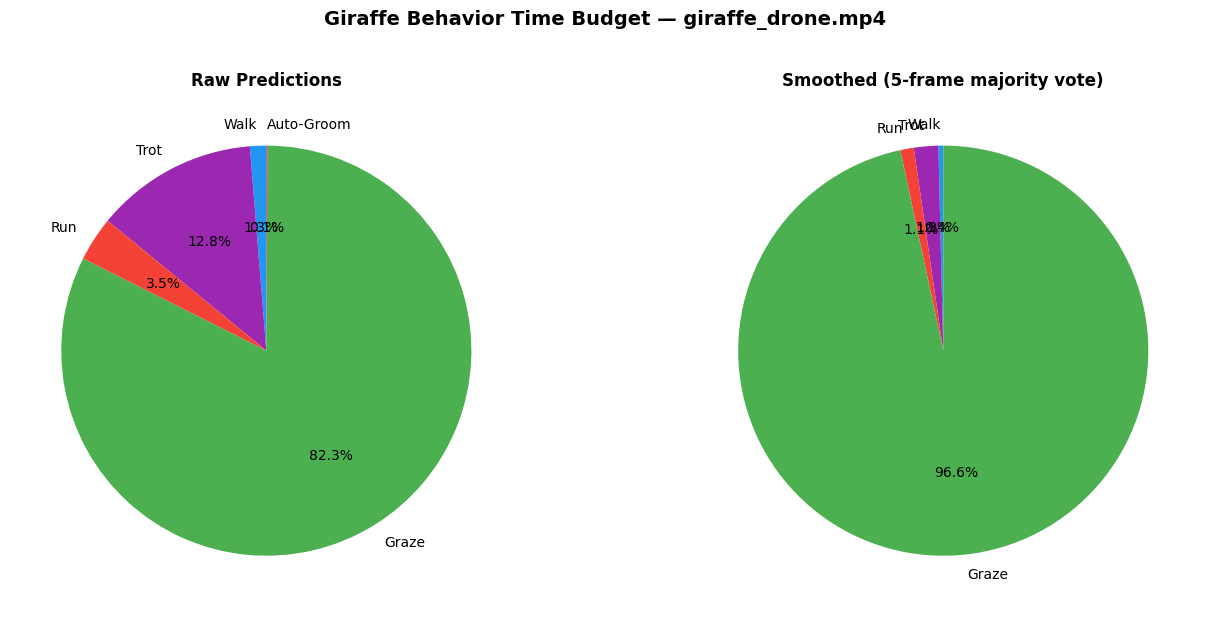

✅ Time budget chart saved.


In [17]:
# ── Temporal smoothing (5-frame majority vote) ────────────────
def smooth_predictions(timeline, window=5):
    """Remove prediction flickering with a rolling majority vote."""
    smoothed     = []
    label_buffer = deque(maxlen=window)
    for t, label, conf in timeline:
        label_buffer.append(label)
        majority = Counter(label_buffer).most_common(1)[0][0]
        smoothed.append((t, majority, conf))
    return smoothed

smoothed  = smooth_predictions(timeline, window=5)
raw_cnt   = Counter(l for _, l, _ in timeline)
smooth_cnt= Counter(l for _, l, _ in smoothed)

# ── Figure 1: Time budget pie charts ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cnts, title in [
    (axes[0], raw_cnt,    'Raw Predictions'),
    (axes[1], smooth_cnt, 'Smoothed (5-frame majority vote)')
]:
    labels = [l for l in LABEL_NAMES[:7] if cnts.get(l, 0) > 0]
    sizes  = [cnts[l] for l in labels]
    colors = [LABEL_COLORS_HEX[LABEL_NAMES.index(l)] for l in labels]
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 10})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle(f'{SPECIES_NAME} Behavior Time Budget — {os.path.basename(VIDEO_PATH)}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'time_budget.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Time budget chart saved.')

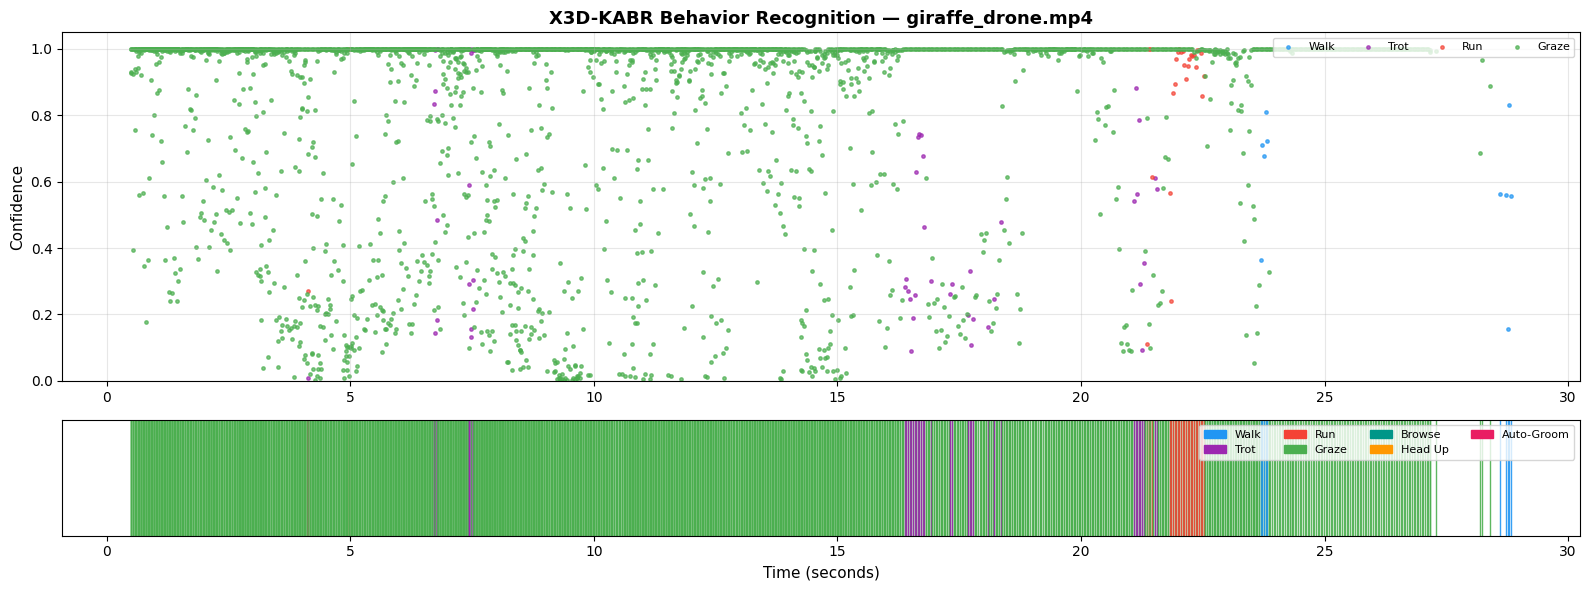

✅ Behavior timeline saved.


In [18]:
# ── Figure 2: Behavior timeline ───────────────────────────────
label_to_idx = {l: i for i, l in enumerate(LABEL_NAMES)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6),
                                gridspec_kw={'height_ratios': [3, 1]})

# Scatter plot: confidence over time, colored by behavior
for i, lbl in enumerate(LABEL_NAMES[:7]):
    pts = [(t, c) for t, l, c in smoothed if l == lbl]
    if pts:
        ts, cs = zip(*pts)
        ax1.scatter(ts, cs, label=lbl, color=LABEL_COLORS_HEX[i], s=6, alpha=0.7)

ax1.set_ylabel('Confidence', fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.legend(loc='upper right', fontsize=8, ncol=4)
ax1.set_title(f'X3D-KABR Behavior Recognition — {os.path.basename(VIDEO_PATH)}',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Color strip
times = [t for t, _, _ in smoothed]
dt    = (times[1] - times[0]) if len(times) > 1 else 0.1
for t, lbl, _ in smoothed:
    idx = label_to_idx.get(lbl, 7)
    ax2.axvspan(t - dt/2, t + dt/2, color=LABEL_COLORS_HEX[idx], alpha=0.9)

patches = [mpatches.Patch(color=LABEL_COLORS_HEX[i], label=l)
           for i, l in enumerate(LABEL_NAMES[:7])]
ax2.legend(handles=patches, loc='upper right', fontsize=8, ncol=4)
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'behavior_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Behavior timeline saved.')